Zadanie 1

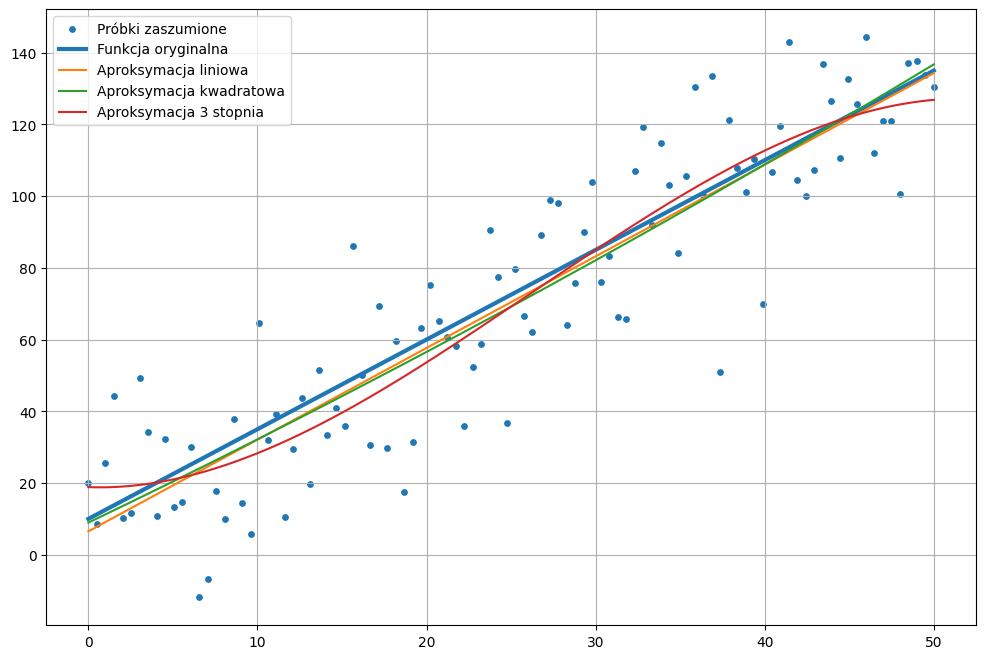

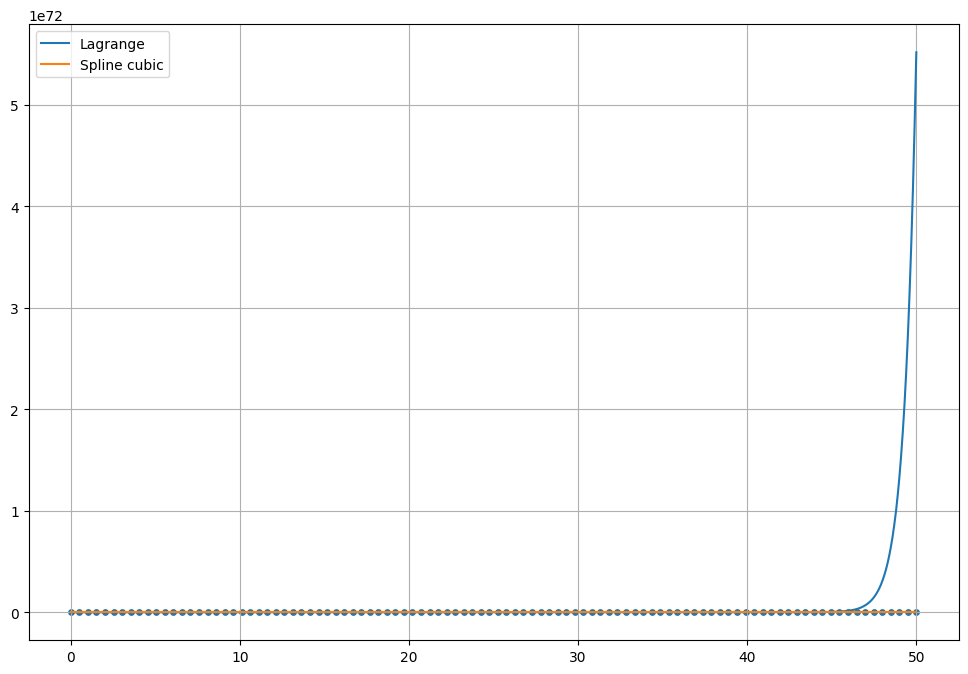

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, interp1d


# FUNKCJA ORYGINALNA


a = 2.5
b = 10

def f(x):
    return a*x + b


# GENEROWANIE DANYCH


np.random.seed(42)

x = np.linspace(0, 50, 100)

y_true = f(x)

noise = np.random.normal(0, 20, 100)

y_noisy = y_true + noise


# FUNKCJE DO APROKSYMACJI


def linear(x, a, b):
    return a*x + b

def quadratic(x, a, b, c):
    return a*x**2 + b*x + c

def cubic(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d


# REGRESJA


p_lin, _ = curve_fit(linear, x, y_noisy)

p_quad, _ = curve_fit(quadratic, x, y_noisy)

p_cubic, _ = curve_fit(cubic, x, y_noisy)


# INTERPOLACJA


lag_poly = lagrange(x, y_noisy)

spline = interp1d(
    x,
    y_noisy,
    kind='cubic'
)


# WYKRES


x_dense = np.linspace(0, 50, 1000)

plt.figure(figsize=(12,8))

plt.scatter(x, y_noisy, s=15, label='Próbki zaszumione')

plt.plot(x_dense,
         f(x_dense),
         linewidth=3,
         label='Funkcja oryginalna')

plt.plot(x_dense,
         linear(x_dense, *p_lin),
         label='Aproksymacja liniowa')

plt.plot(x_dense,
         quadratic(x_dense, *p_quad),
         label='Aproksymacja kwadratowa')

plt.plot(x_dense,
         cubic(x_dense, *p_cubic),
         label='Aproksymacja 3 stopnia')

plt.legend()
plt.grid()
plt.show()


# INTERPOLACJA


plt.figure(figsize=(12,8))

plt.scatter(x, y_noisy, s=15)

plt.plot(x_dense,
         lag_poly(x_dense),
         label='Lagrange')

plt.plot(x_dense,
         spline(x_dense),
         label='Spline cubic')

plt.legend()
plt.grid()
plt.show()

Zadanie 2

In [7]:
import numpy as np
from scipy.interpolate import CubicSpline


# DANE


t = np.array([0,1,2,3])

s = np.array([0.0,42.7,73.2,92.5])


# SPLAJN


cs = CubicSpline(t, s)


# SZUKANIE MOMENTU


times = np.linspace(0, 3, 10000)

positions = cs(times)

idx = np.argmin(np.abs(positions - 79.6))

t_radar = times[idx]


# PRĘDKOŚĆ


velocity = cs.derivative()(t_radar)

print("Moment minięcia radaru:")
print(t_radar)

print("Prędkość w tym momencie:")
print(velocity)

Moment minięcia radaru:
2.275727572757276
Prędkość w tym momencie:
21.683197365641135


Zadanie 3

a = 4.078787878787879
b = 47.266666666666644
Przewidywany wynik dla 12 godzin nauki:
96.21212121212119


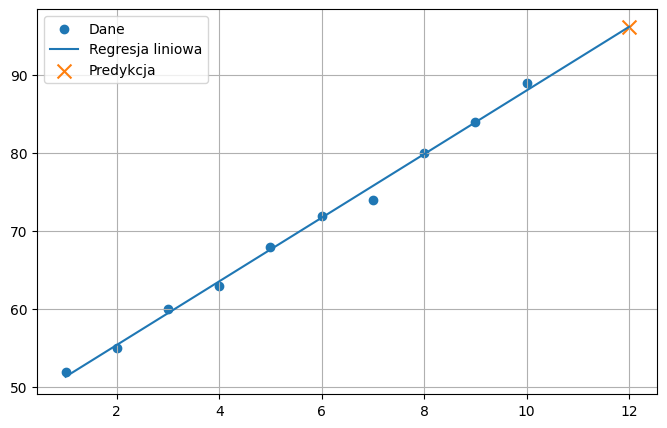

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# PRZYKŁADOWE DANE RZECZYWISTE



x = np.array([1,2,3,4,5,6,7,8,9,10])

y = np.array([52,55,60,63,68,72,74,80,84,89])


# REGRESJA LINIOWA


a, b = np.polyfit(x, y, 1)

print("a =", a)
print("b =", b)


# PREDYKCJA


x_pred = 12

y_pred = a*x_pred + b

print("Przewidywany wynik dla 12 godzin nauki:")
print(y_pred)


# WYKRES


x_plot = np.linspace(1, 12, 200)

plt.figure(figsize=(8,5))

plt.scatter(x, y, label="Dane")

plt.plot(
    x_plot,
    a*x_plot + b,
    label="Regresja liniowa"
)

plt.scatter(
    x_pred,
    y_pred,
    marker='x',
    s=100,
    label="Predykcja"
)

plt.grid()
plt.legend()
plt.show()